# Education Project: Modeling Relationships Between ACT Scores and Socio-Economic Factors
### Brisa Halviatti for Data 5100 Assignment 2


**Objective:** The purpose of the assignment is to perform work using the data science methodology to answer the question of whether school performance is predicted by socioeconomic factors. We will perform and compare various linear regression models to determine whether 'less is more': do the additional predictors from additional datasets add significant value to our model or is a simple reduced model the best fit?  
 
**Key Techniques:** Regression Analysis (see [Data_Prep_Education_Project](https://github.com/brisamh/education/blob/main/code/Data_Prep_Education_Project.ipynb) for data definitions and *extensive* preparation steps)

## Load and Preview Datasource

In [1]:
# Import pandas, numpy, and matplotlib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# data visualization
import seaborn as sns
# set the plotting style
sns.set_style("whitegrid")
import plotly.offline as po
import plotly.graph_objs as pg
po.init_notebook_mode(connected=True)

# Model preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

# Modeling
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Model metrics and analysis
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from statsmodels.stats.anova import anova_lm
from patsy import dmatrices

Import Prepped Dataset

In [2]:
df_final = pd.read_csv(
    'https://raw.githubusercontent.com/brisamh/education/refs/heads/main/data/clean_education_project_data.csv')

In [3]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7251 entries, 0 to 7250
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   rate_unemployment      7251 non-null   float64
 1   percent_college        7251 non-null   float64
 2   percent_married        7251 non-null   float64
 3   median_income          7251 non-null   float64
 4   average_act            7251 non-null   float64
 5   percent_lunch          7251 non-null   float64
 6   state                  7251 non-null   object 
 7   zipcode                7251 non-null   int64  
 8   school_type            7251 non-null   object 
 9   charter                7251 non-null   object 
 10  sch_name               7251 non-null   object 
 11  magnet_sch             7251 non-null   object 
 12  shared_time_sch        7251 non-null   object 
 13  area_size              7227 non-null   object 
 14  area_type              7227 non-null   object 
 15  stud

While Zip Code appears to have become an integer, all other data types appear valid

In [4]:
df_final['zipcode'] = df_final['zipcode'].astype(str)

In [5]:
pd.set_option('display.max_columns', None)
df_final.head()

,rate_unemployment,percent_college,percent_married,median_income,average_act,percent_lunch,state,zipcode,school_type,charter,sch_name,magnet_sch,shared_time_sch,area_size,area_type,student_cnt,teacher_cnt,student_teacher_ratio,jj,arrests,referrals,referrals_or_arrests,any_ref_or_arr,institution_count,any_institutions,testing
0,0.117962,0.445283,0.346495,42820.0,20.433455,0.066901,DE,19804,Regular School,Yes,DELAWARE MILITARY ACADEMY,No,No,Large,Suburb,584.0,25.0,23.36,No,0.0,2.0,2.0,True,0.0,False,Mandatory
1,0.063984,0.662765,0.767619,89320.0,19.498168,0.112412,DE,19709,Regular School,No,MIDDLETOWN HIGH SCHOOL,No,No,Fringe,Town,1499.0,87.0,17.23,No,4.0,46.0,50.0,True,0.0,False,Mandatory
2,0.056460,0.701864,0.713090,84140.0,19.554335,0.096816,DE,19709,Regular School,No,APPOQUINIMINK HIGH SCHOOL,No,No,Fringe,Rural,1638.0,95.0,17.24,No,0.0,24.0,24.0,True,0.0,False,Mandatory
3,0.044739,0.692062,0.641283,56500.0,17.737485,0.296960,DE,19958,Regular School,No,CAPE HENLOPEN HIGH SCHOOL,No,No,Distant,Town,1406.0,98.0,14.35,No,0.0,0.0,0.0,False,0.0,False,Mandatory
4,0.077014,0.640060,0.834402,54015.0,18.245421,0.262641,DE,19934,Regular School,No,CAESAR RODNEY HIGH SCHOOL,No,No,Mid-size,Suburb,1996.0,134.0,14.90,No,8.0,56.0,64.0,True,0.0,False,Mandatory


## Summary Statistics

In [6]:
print(f'There are {len(df_final)} schools in our sample from {df_final['state'].nunique()} states')

There are 7251 schools in our sample from 20 states


In [7]:
df_final['average_act'].describe()

count    7251.000000
mean       20.288184
std         2.515746
min        12.362637
25%        18.785104
50%        20.500000
75%        22.000000
max        32.362637
Name: average_act, dtype: float64

The aveage ACT Score is about 20, with a standard deviation of 2.5

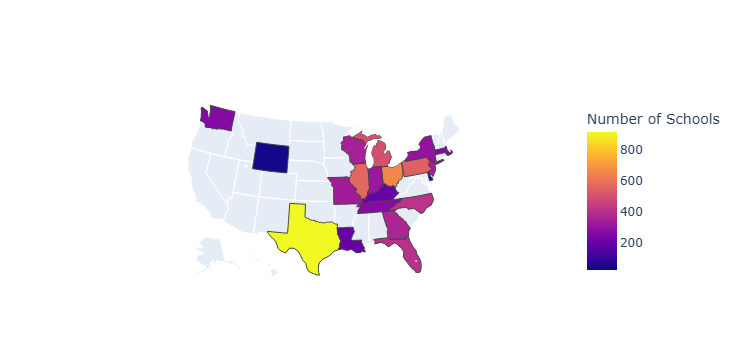

In [8]:
layout = dict(
    geo={"scope": "usa"},
    coloraxis_colorbar=dict(title="Number of Schools")
)

data = dict(
    type="choropleth",
    locations=df_final["state"].value_counts().index,
    locationmode="USA-states",
    z=df_final["state"].value_counts().values,
    coloraxis="coloraxis"
)

x = pg.Figure(data=[data], layout=layout)
po.iplot(x)

In [9]:
state_counts = df_final['state'].value_counts().rename_axis('state').reset_index(name='count')
state_counts['percent'] = (state_counts['count'] / state_counts['count'].sum() * 100).round(2)
state_counts

,state,count,percent
0,TX,913,12.59
1,OH,654,9.02
2,IL,565,7.79
3,PA,546,7.53
4,MI,500,6.90
5,NC,409,5.64
6,FL,404,5.57
7,GA,367,5.06
8,WI,351,4.84
9,NJ,339,4.68


Texas schools make up almost 13% of the sample, Washington is the only state representing the West Coast, and Wyoming is the only state representing the Midwest. We know that this sample is not going to be the most representative of the entire United States, but can offer some relationships between the relationships in our data

In [10]:
df_final.groupby('testing')['state'].unique()

testing
Mandatory                            [DE, IN, KY, MI]
Optional     [IL, LA, MA, MO, NJ, NC, OH, TN, WI, WY]
Provided                     [FL, GA, NY, PA, TX, WA]
Name: state, dtype: object

Half of the states do not provide or mandate any standardized testing-- it is manadatory in four and free testing is provided in 6.

In [11]:
df_final['testing'].value_counts(normalize=True).round(3)

testing
Optional     0.471
Provided     0.385
Mandatory    0.144
Name: proportion, dtype: float64

Texas, Ohio, and Illinois the states with the most schools represented, and they are testing 'Optional'. This is important to note since we can assume that schools with mandatory testing will have lower reported ACT scores, simply because non-college bound students will also be taking these tests. 

In [12]:
df_final.groupby('testing')[['average_act']].mean()

,average_act
testing,
Mandatory,19.808473
Optional,20.585132
Provided,20.104354


## Begin Analysis

We will visualize the full relationships present in our data using a pair plot. We can omit boolean data for this view.

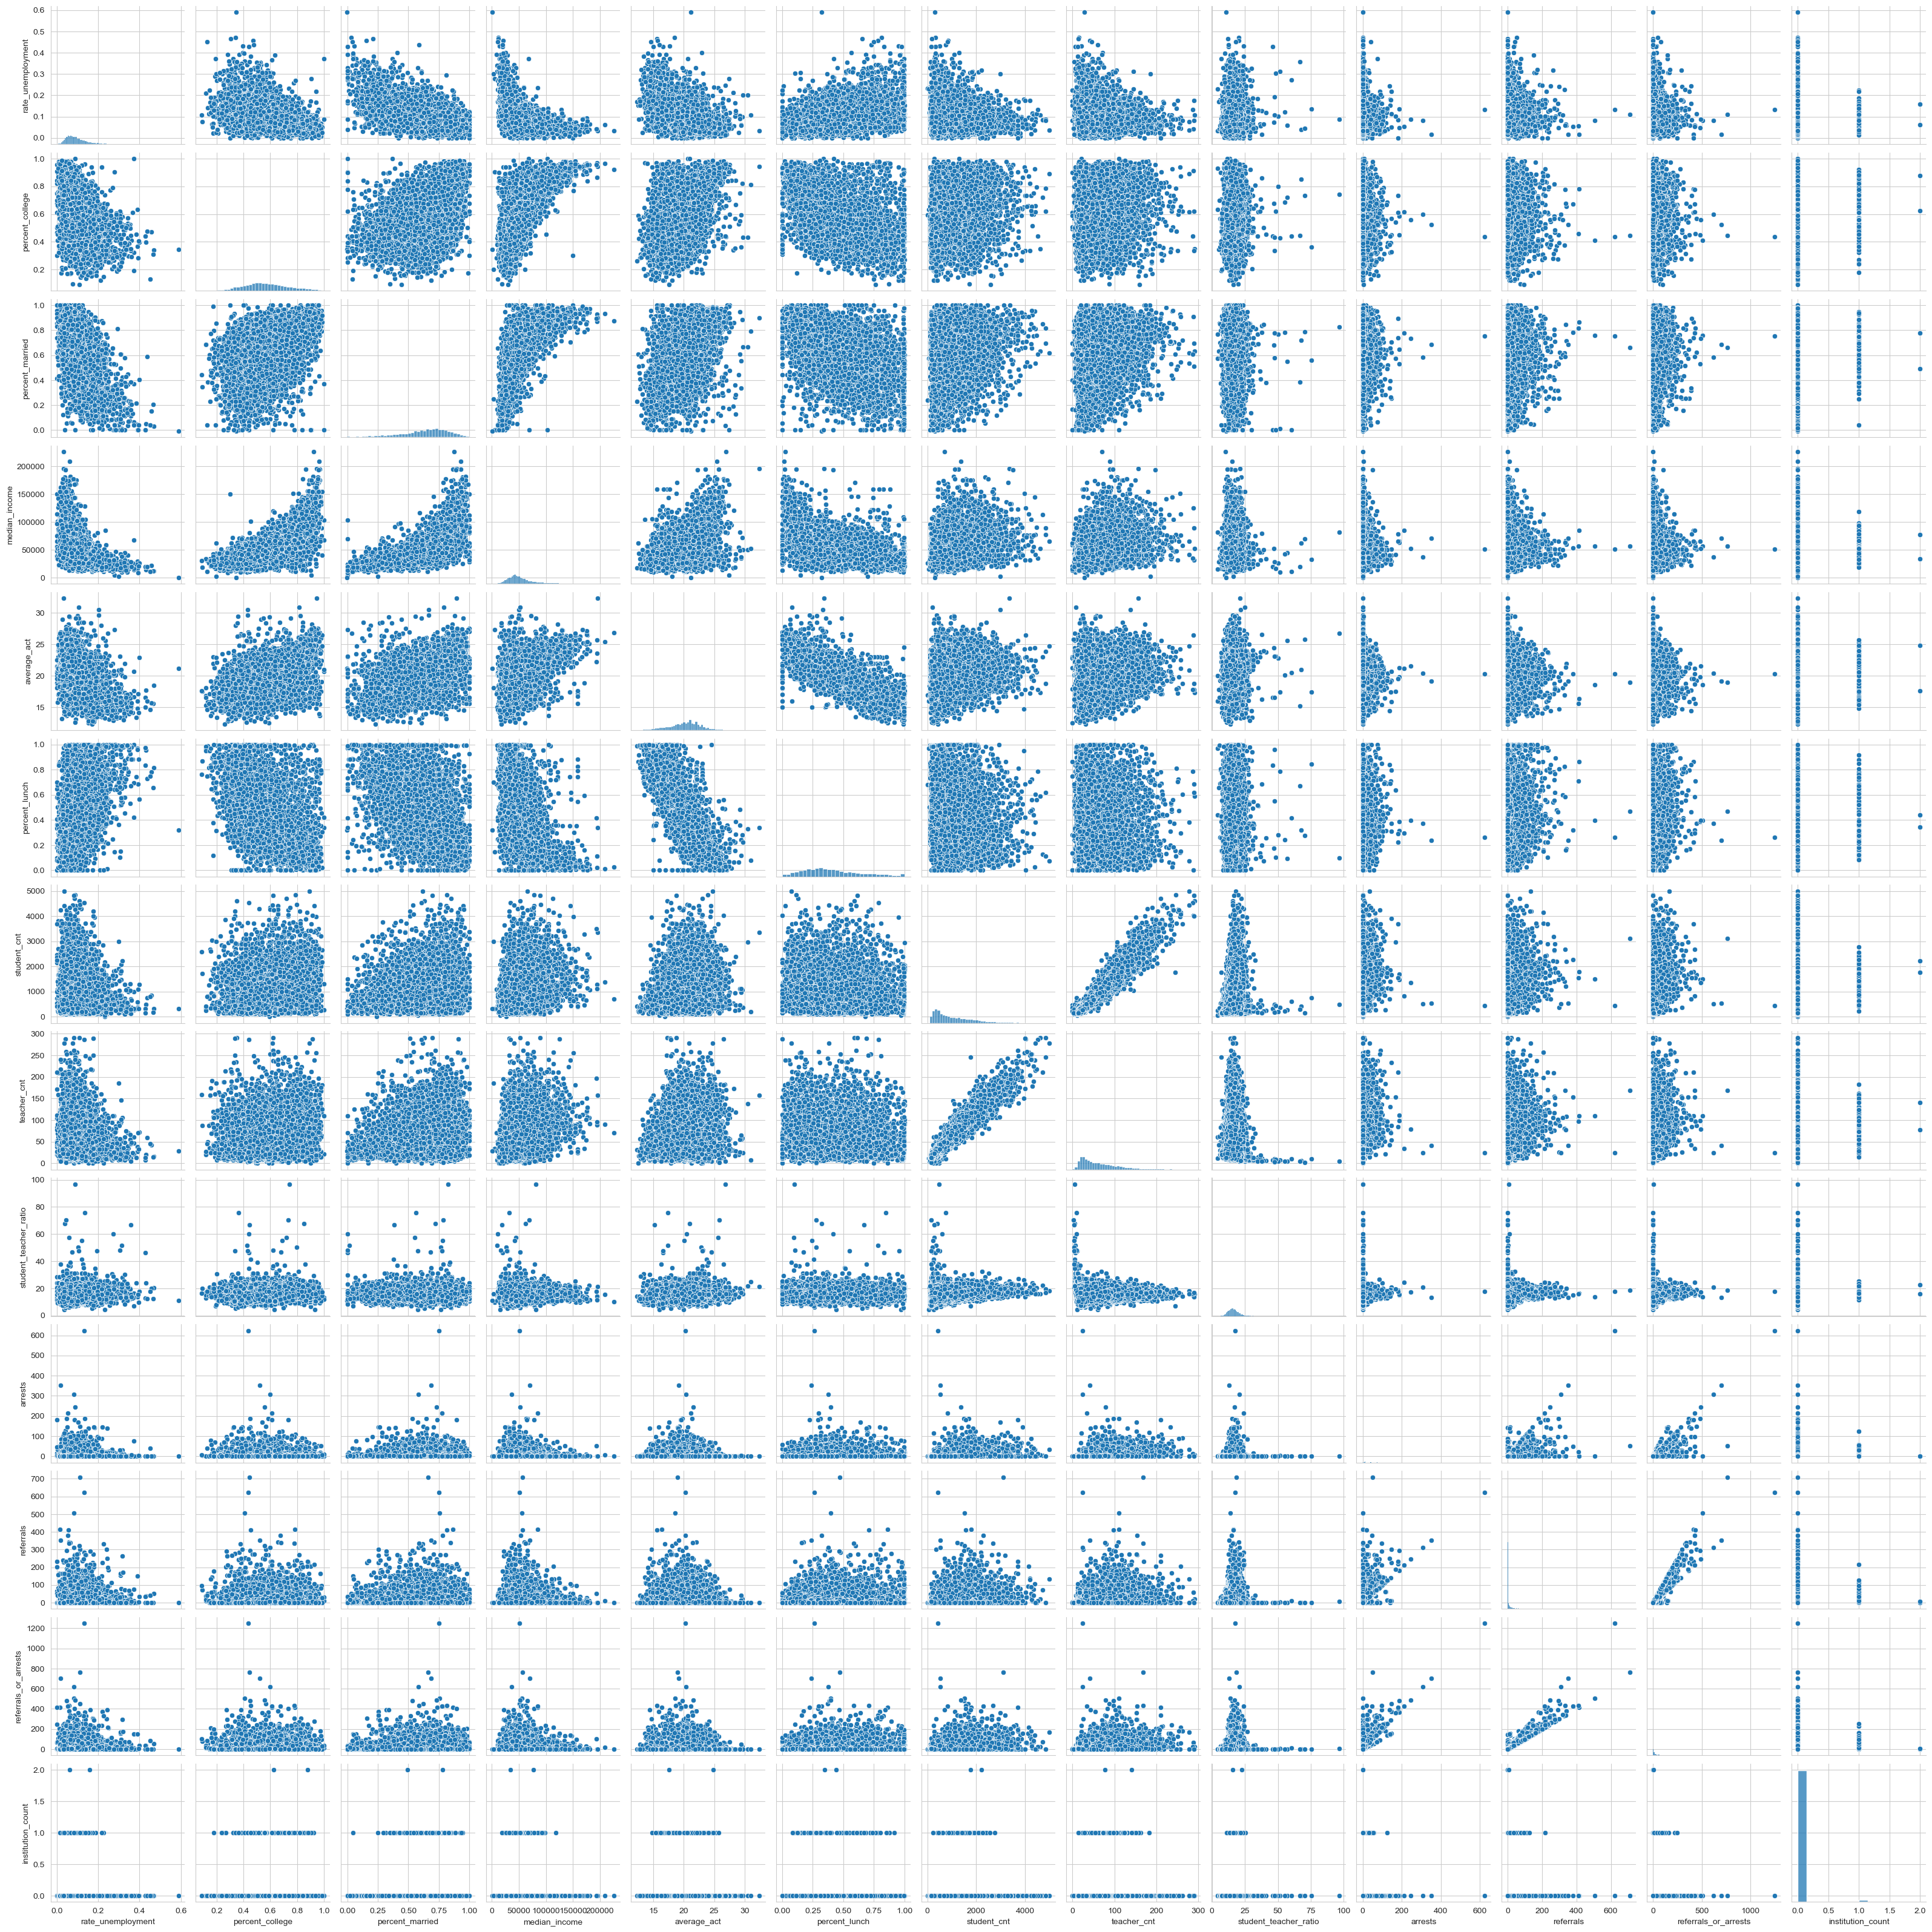

In [13]:
sns.pairplot(
    df_final.drop(columns=['any_institutions', 'any_ref_or_arr'])
)
plt.show()

While not easy to see, there is indication of multicollinearity between some of our predictors: 
* Student Count and Teacher Count have nearly a 1:1 relationship, which makes sense.
* Referrals and Arrests also have a strong relationship, which again makes complete sense.
* Teacher Count and area Median Income also appear to have some signal to a relationship. 

Zoom in on the variables for Average ACT, in two blocks:

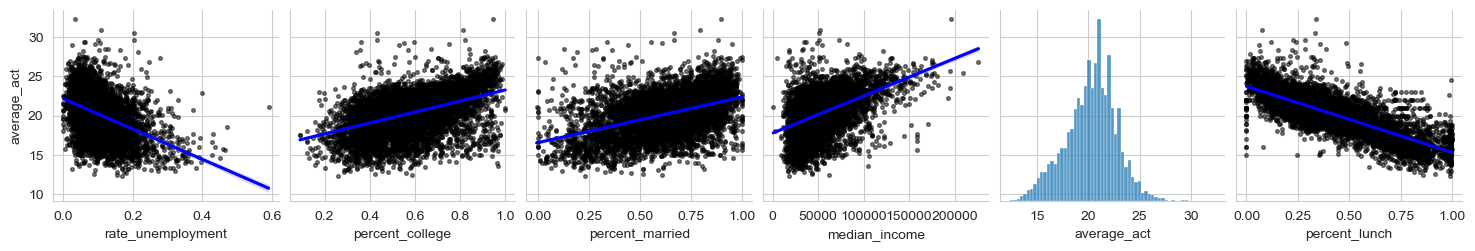

In [14]:
fig = sns.pairplot(
    df_final,
    y_vars=['average_act'],
    x_vars=['rate_unemployment',
 'percent_college',
 'percent_married',
 'median_income',
 'average_act',
 'percent_lunch'],  
    kind='reg',
    plot_kws={
        "line_kws": {'color':'blue'},
        "scatter_kws": {"alpha":0.5, "color":"k", "s":7},
    }
)


Above we have the variables provided in our EdGap data, and below we have the data I have independently sourced:

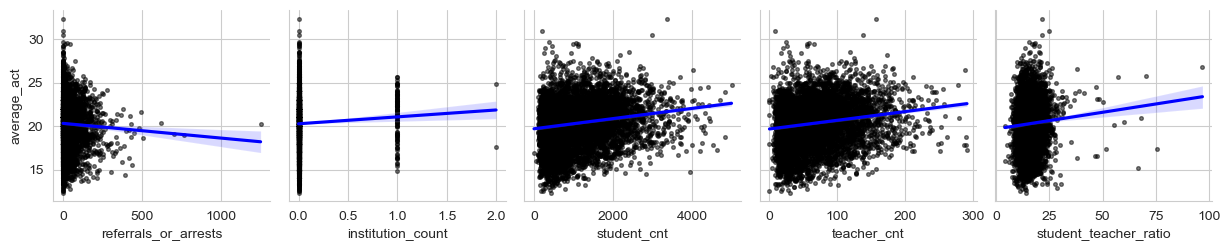

In [15]:
fig = sns.pairplot(
    df_final,
    y_vars=['average_act'],
    x_vars=['referrals_or_arrests', 'institution_count','student_cnt','teacher_cnt','student_teacher_ratio'],  
    kind='reg',
    plot_kws={
        "line_kws": {'color':'blue'},
        "scatter_kws": {"alpha":0.5, "color":"k", "s":7},
    }
)

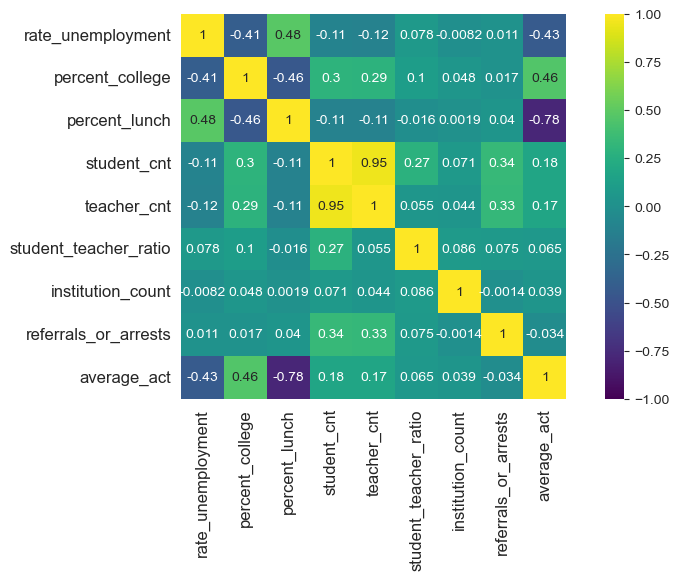

In [16]:
predictor_variables = ['rate_unemployment', 'percent_college', 'percent_lunch', 'state', 'charter'
                       ,'magnet_sch','shared_time_sch','student_cnt','teacher_cnt','student_teacher_ratio'
                       ,'any_institutions','institution_count','testing','area_type','area_size','any_ref_or_arr','referrals_or_arrests']


numerical_predictors = df_final[predictor_variables].select_dtypes(include='number').columns.to_list()

corr_matrix = df_final[numerical_predictors + ["average_act"]].corr()

plt.figure(figsize=(10, 5))

sns.heatmap(
    corr_matrix, vmax=1, vmin=-1, square=True, annot=True, cmap="viridis"
)

plt.tick_params(labelsize=12)

plt.show()

#### Categorical Analysis

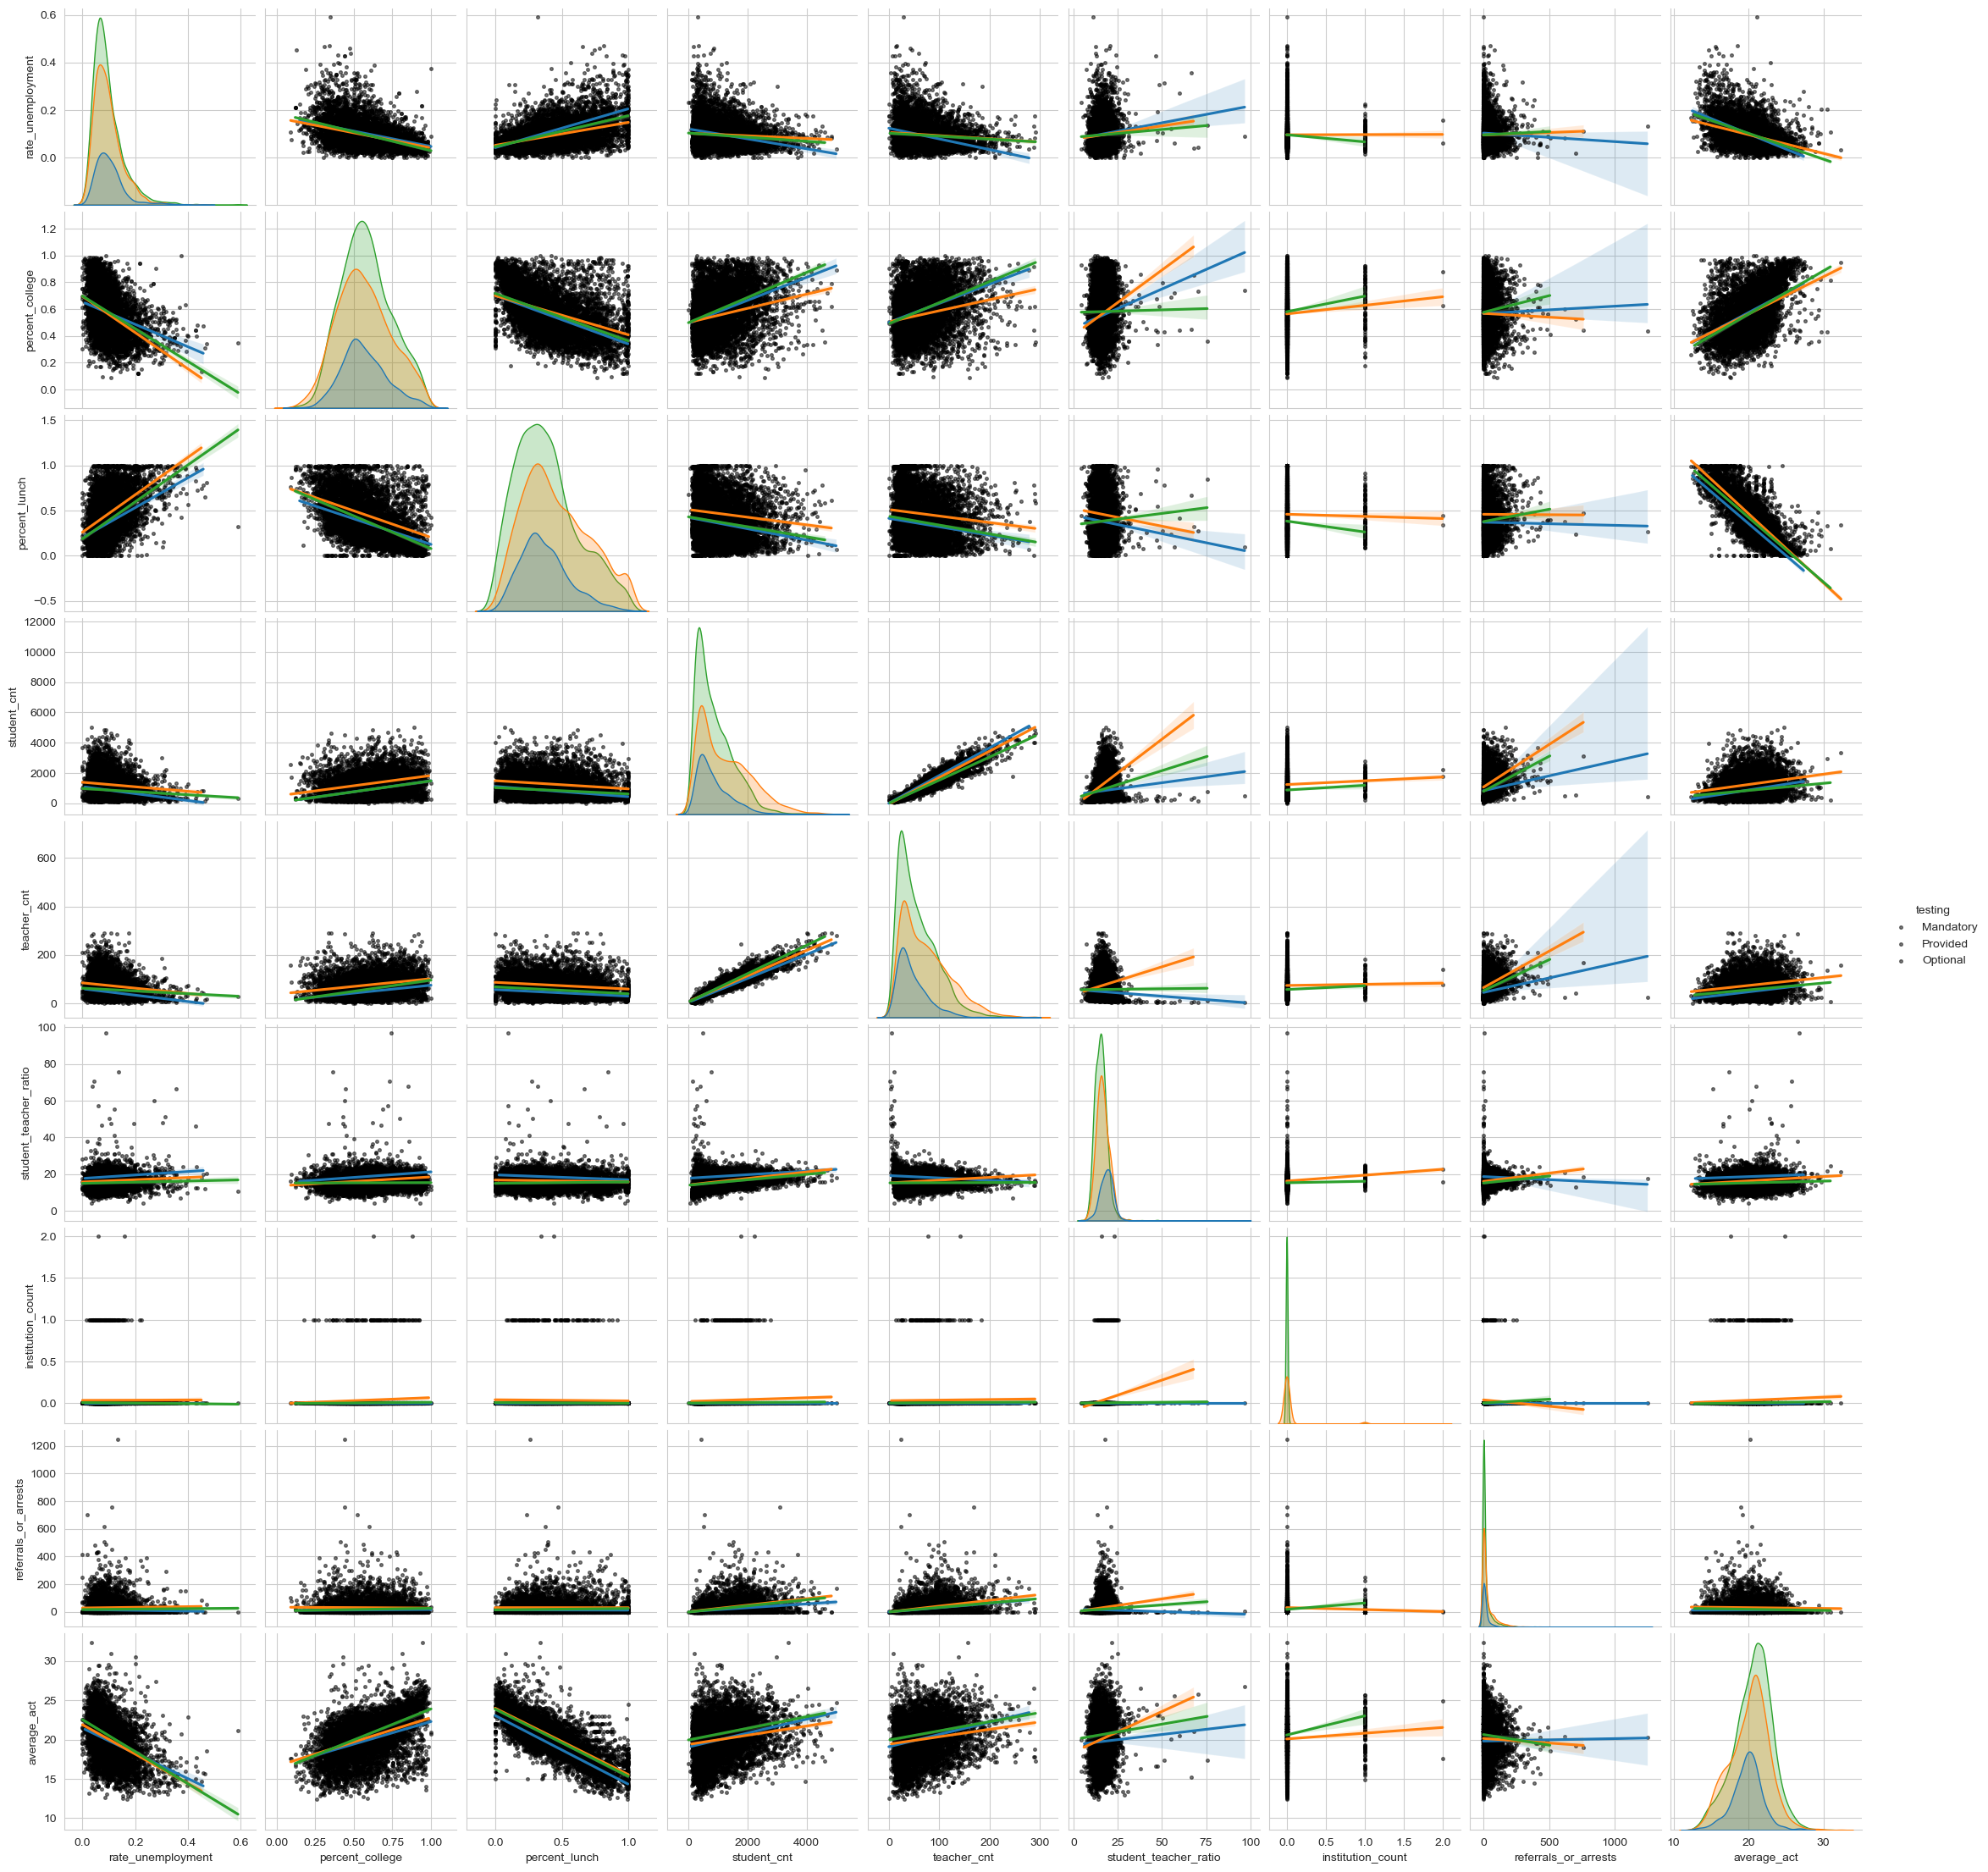

In [17]:
fig = sns.pairplot(
    data=df_final,
    vars=numerical_predictors + ['average_act'],
    hue='testing',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)
plt.show()

Blue = Mandatory Testing, Orange = Provided Testing, Green = Optional Testing.

There is some indication that student teacher ratio has a stronger relationship to ACT for schools where testing is provided but not mandated

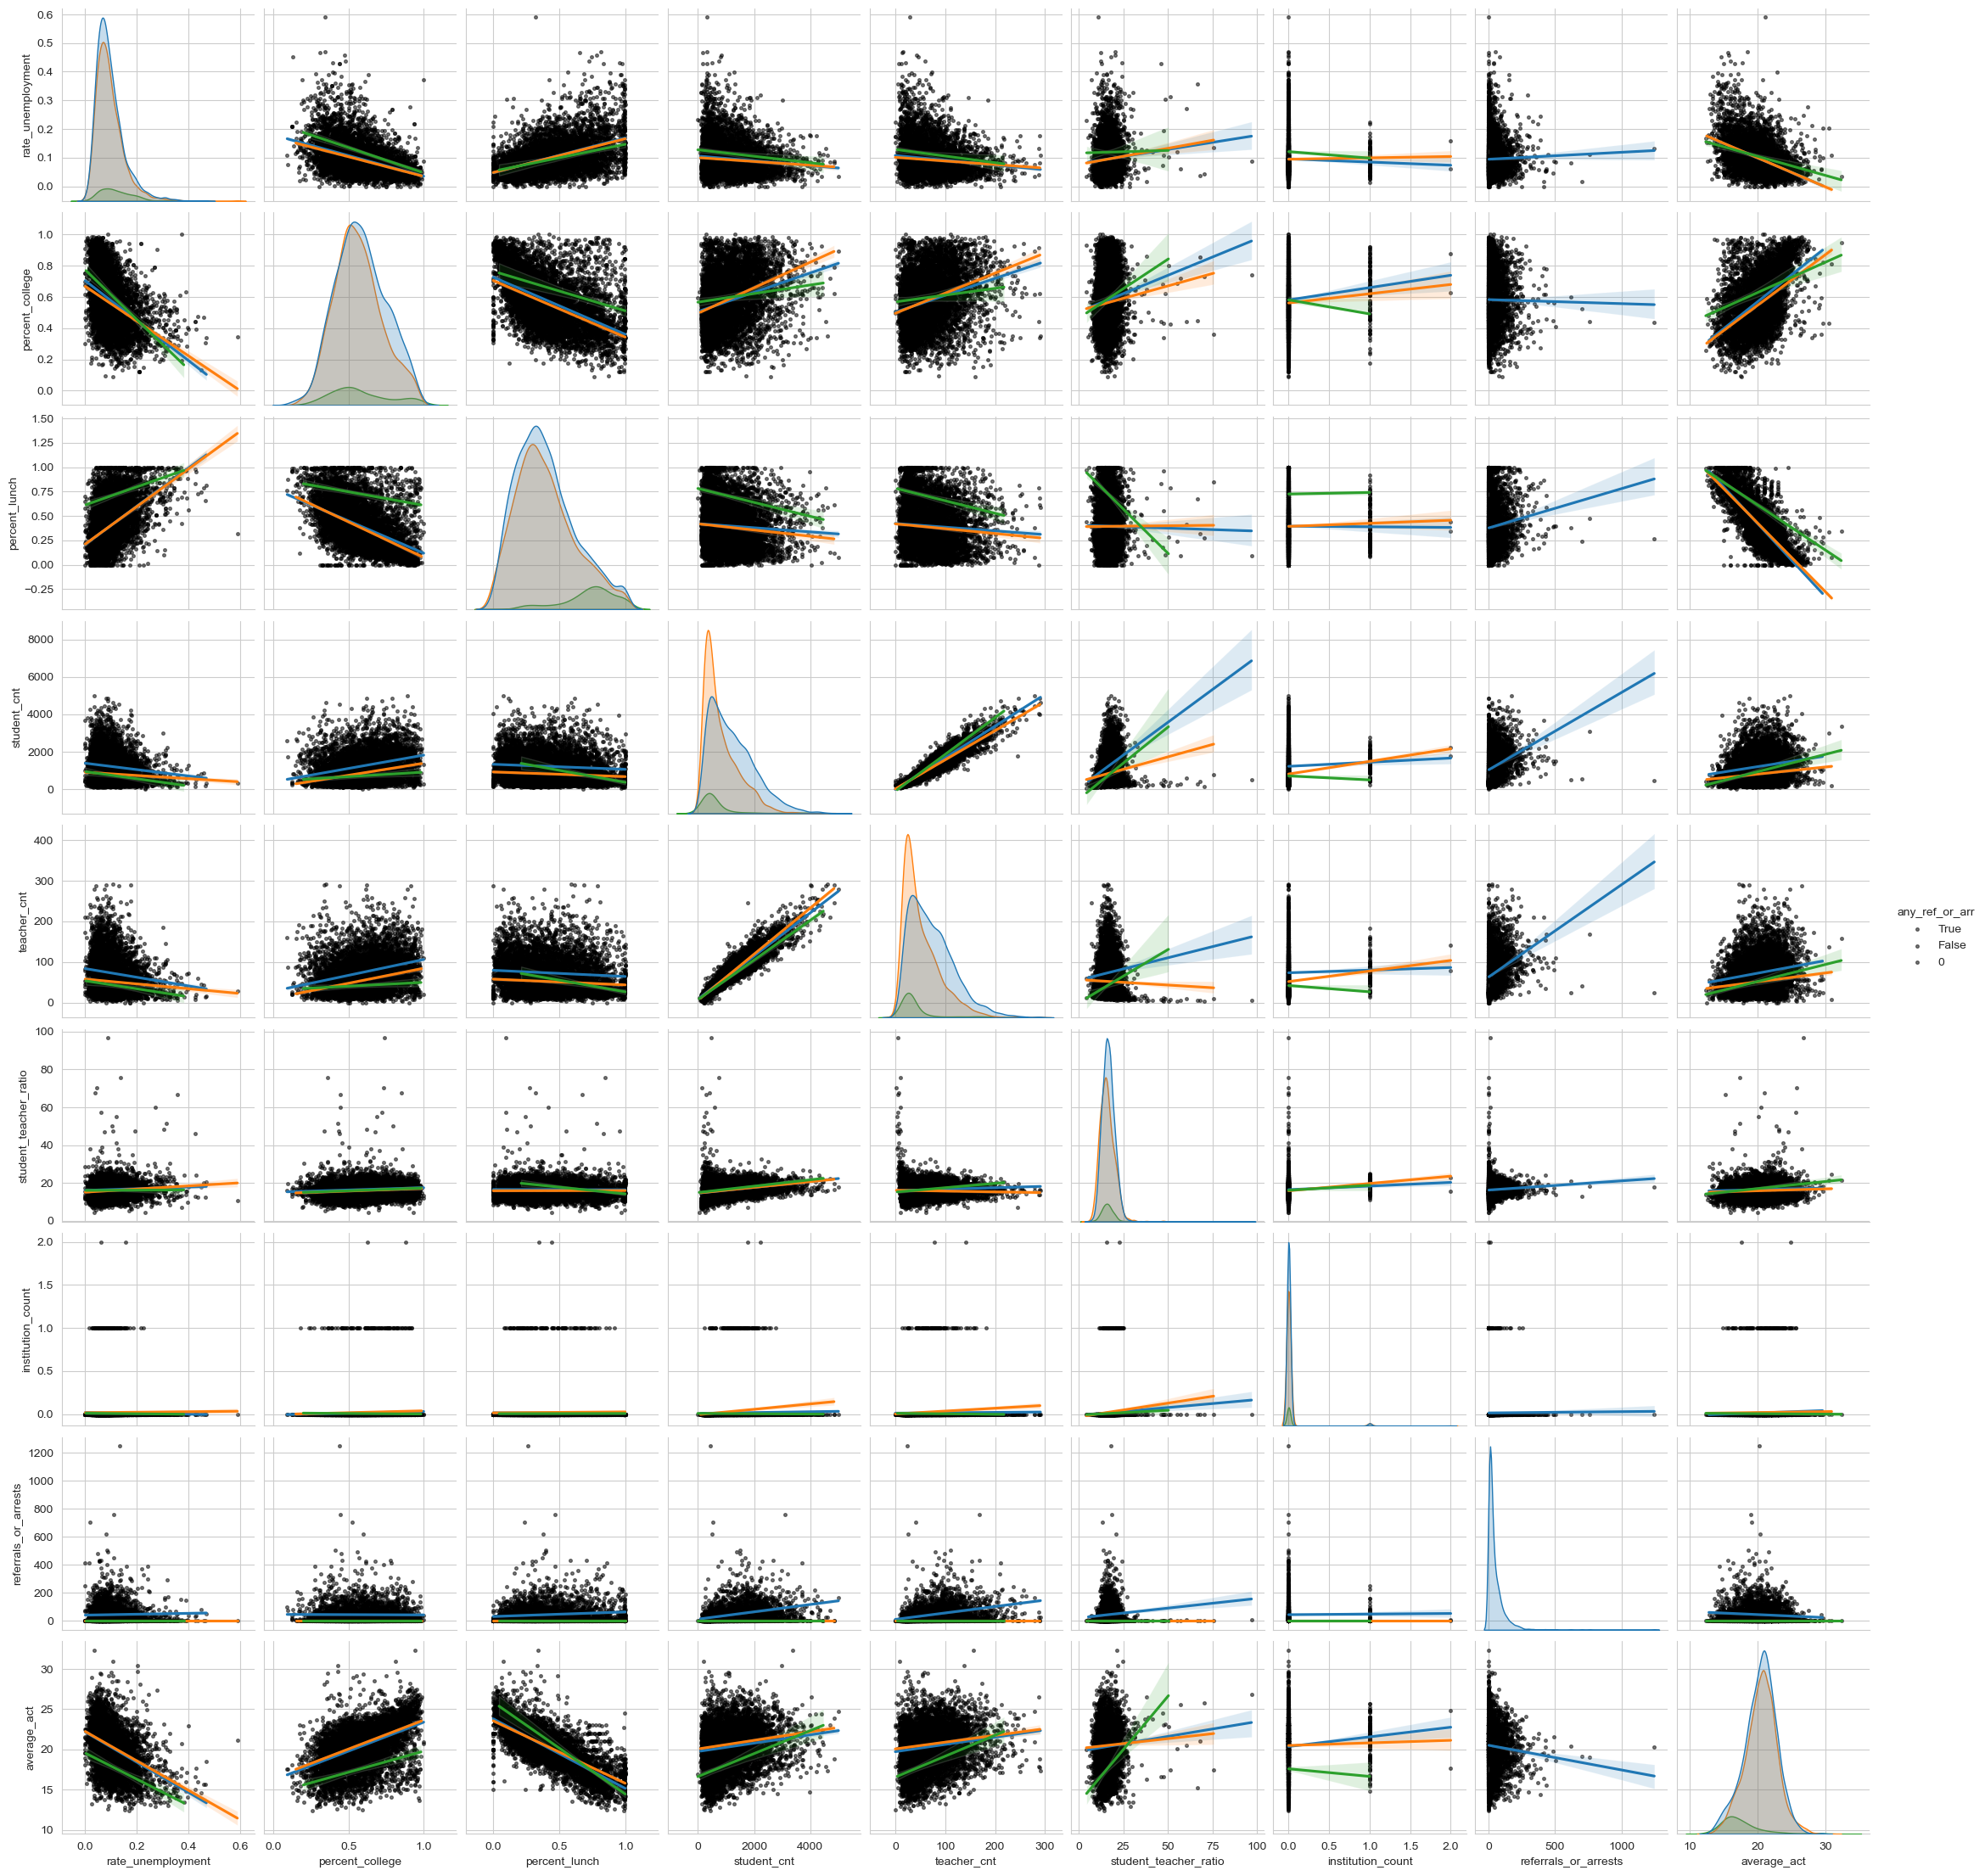

In [18]:
fig = sns.pairplot(
    data=df_final,
    vars=numerical_predictors + ['average_act'],
    hue='any_ref_or_arr',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)
plt.show()

Blue = Arrests/Referrals made, Orange = No Arrest/Referrals Made, Green = No Data.

No immediate indiciations that referrals and arrests will have much impact.

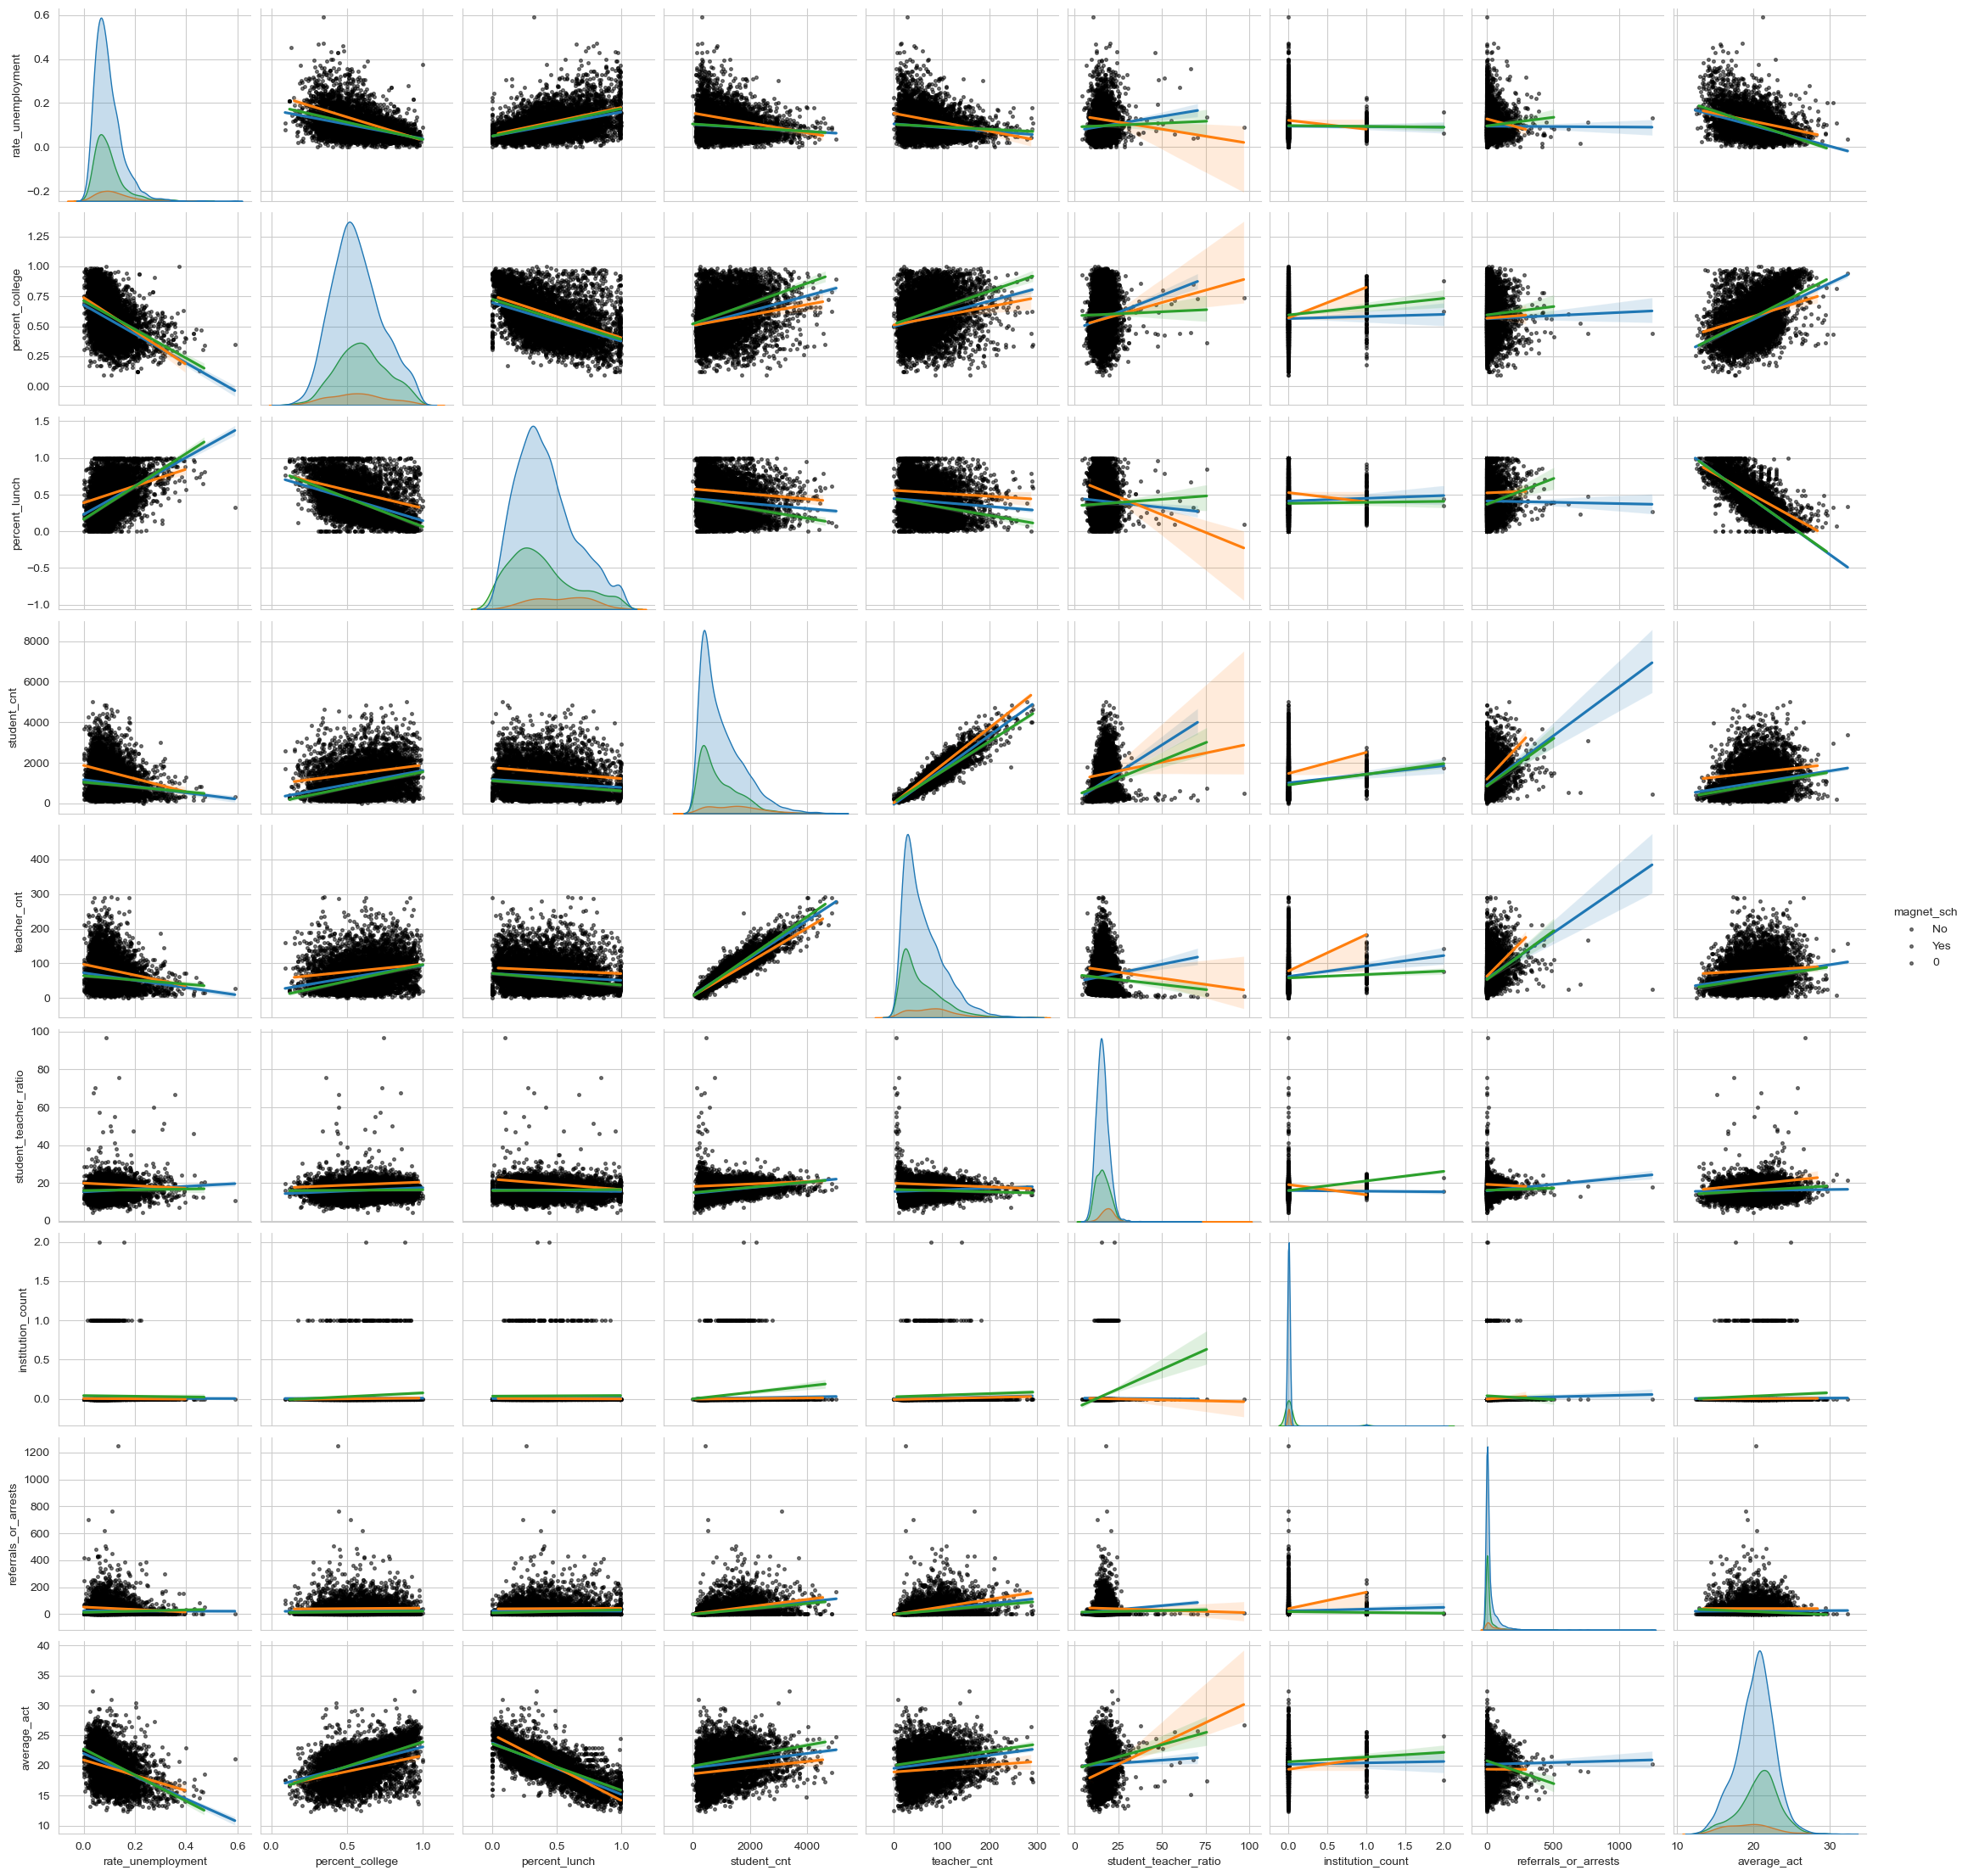

In [19]:
fig = sns.pairplot(
    data=df_final,
    vars=numerical_predictors + ['average_act'],
    hue='magnet_sch',
    kind="reg",
    plot_kws={"scatter_kws": {"alpha": 0.5, "color": "k", "s": 7},
    },
)
plt.show()

Blue = Not a Magnet School, Orange = Magnet School, Green = Optional Testing.
My assumption is there are too few "Magnet Schools" to make a significant difference.

## Begin Multivariate Regression Model

We are going to start with a full model, then reduce the model until we have struck a balance of explanatory power without over fitting

In [20]:
multivariate_model = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch + student_cnt + teacher_cnt + student_teacher_ratio + institution_count + referrals_or_arrests + C(charter) + C(magnet_sch) + C(shared_time_sch) + C(testing) +  C(area_type) + C(area_size) + any_institutions + any_ref_or_arr',
    data=df_final).fit()


In [21]:
print(multivariate_model.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.661
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     537.9
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:36:47   Log-Likelihood:                -12949.
No. Observations:                7209   AIC:                         2.595e+04
Df Residuals:                    7182   BIC:                         2.614e+04
Df Model:                          26                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

The sheer number of variables is cause for concern, adding variables will certainly improve model fit but we will most likely be overfitting. We do see multiple variables that are statistically significant, however very few of the model coefficients have a large increase or decrease on the score itself. 

For example, all else held constant our model tells us that 1 additional referral or arrest leads to a -0.0014 point decrase in the average ACT score. While very significant (P-value of 0.000) this is a meaningless change in overall score. 

### Shedding Predictors
We will use a design matrix to pass through our results and remove all statistically insignificant predictors based on p-values > 0.05

In [22]:
y, X_design = dmatrices('average_act ~ rate_unemployment + percent_college + percent_lunch + student_cnt + teacher_cnt + student_teacher_ratio + institution_count + referrals_or_arrests + C(charter) + C(magnet_sch) + C(shared_time_sch) + C(testing) +  C(area_type) + C(area_size) + any_institutions + any_ref_or_arr',
                        data=df_final,
                        return_type='dataframe'
                        )

In [23]:
X_design.head()

,Intercept,C(charter)[T.Not applicable],C(charter)[T.Yes],C(magnet_sch)[T.No],C(magnet_sch)[T.Yes],C(shared_time_sch)[T.No],C(shared_time_sch)[T.Yes],C(testing)[T.Optional],C(testing)[T.Provided],C(area_type)[T.Rural],C(area_type)[T.Suburb],C(area_type)[T.Town],C(area_size)[T.Fringe],C(area_size)[T.Large],C(area_size)[T.Mid-size],C(area_size)[T.Remote],C(area_size)[T.Small],any_institutions[T.True],any_ref_or_arr[T.False],any_ref_or_arr[T.True],rate_unemployment,percent_college,percent_lunch,student_cnt,teacher_cnt,student_teacher_ratio,institution_count,referrals_or_arrests
0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.117962,0.445283,0.066901,584.0,25.0,23.36,0.0,2.0
1,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.063984,0.662765,0.112412,1499.0,87.0,17.23,0.0,50.0
2,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.056460,0.701864,0.096816,1638.0,95.0,17.24,0.0,24.0
3,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.044739,0.692062,0.296960,1406.0,98.0,14.35,0.0,0.0
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.077014,0.640060,0.262641,1996.0,134.0,14.90,0.0,64.0


The predictors we will keep, and re-run:

In [24]:
X = X_design.loc[:, multivariate_model.pvalues<0.05]

print(X.columns)

Index(['Intercept', 'C(shared_time_sch)[T.No]', 'C(shared_time_sch)[T.Yes]',
       'C(testing)[T.Optional]', 'C(testing)[T.Provided]',
       'C(area_type)[T.Rural]', 'C(area_type)[T.Town]',
       'C(area_size)[T.Fringe]', 'C(area_size)[T.Large]',
       'C(area_size)[T.Mid-size]', 'C(area_size)[T.Small]',
       'any_ref_or_arr[T.False]', 'any_ref_or_arr[T.True]',
       'rate_unemployment', 'percent_college', 'percent_lunch', 'teacher_cnt',
       'student_teacher_ratio', 'referrals_or_arrests'],
      dtype='object')


In [25]:
multivariate_model_significant = sm.OLS(y, X).fit()

In [26]:
print(multivariate_model_significant.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.660
Model:                            OLS   Adj. R-squared:                  0.659
Method:                 Least Squares   F-statistic:                     820.4
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:36:47   Log-Likelihood:                -12958.
No. Observations:                7209   AIC:                         2.595e+04
Df Residuals:                    7191   BIC:                         2.608e+04
Df Model:                          17                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

To reduce the model further, I will drop:
* Teacher Counts
* Referrals or Arrests

Teacher counts are one of two inputs that make up the student:teacher ratio predictor and the coefficients for this variable are marginal at best. While statistically significant, I am also dropping referrals_or_arrests since the coefficient is tiny at -0.0015, and is correlated to the T/F flag for 'any_ref_or_arr'

In [27]:
X = X.drop(
    columns=['referrals_or_arrests', 'teacher_cnt'])

In [28]:
multivariate_model_significant = sm.OLS(y, X).fit()

In [29]:
print(multivariate_model_significant.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.656
Model:                            OLS   Adj. R-squared:                  0.656
Method:                 Least Squares   F-statistic:                     915.3
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:36:47   Log-Likelihood:                -12996.
No. Observations:                7209   AIC:                         2.602e+04
Df Residuals:                    7193   BIC:                         2.613e+04
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

As one final pass at reducing the model, I will eliminate:
* student_teacher_ratio since the coefficient is again very small
* 'C(area_size)[T.Fringe]' which is on the cusp of no longer being statistically significant

In [30]:
X = X.drop(
    columns=['student_teacher_ratio','C(area_size)[T.Fringe]'])

multivariate_model_significant = sm.OLS(y, X).fit()

In [31]:
print(multivariate_model_significant.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.651
Model:                            OLS   Adj. R-squared:                  0.650
Method:                 Least Squares   F-statistic:                     1030.
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:36:47   Log-Likelihood:                -13055.
No. Observations:                7209   AIC:                         2.614e+04
Df Residuals:                    7195   BIC:                         2.623e+04
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------------
Intercept             

Our slightly reduced, highly significant, multivariate model is still concerning. We do have highly significant values, a solid R-Squared value of .651, an adjusted R-Squared of roughly the same value, and a valid and significant F-Statistic of 1030. 

Conversely, our AIC has gone down each time we've removed predictors -- so despite making our model simpler these changes are not providing us improvement on this particular metric. We also have a high likelihood of multicollinearity amoung our predictors, as indicated in the summary notes point 2. Most likely this is because our area_size and area_type variables were once a single column. I would also expect Unemployment and Median Income (a census tract data point) to correlate with the area_type and area_size. 

In [32]:
print(X.columns)

Index(['Intercept', 'C(shared_time_sch)[T.No]', 'C(shared_time_sch)[T.Yes]',
       'C(testing)[T.Optional]', 'C(testing)[T.Provided]',
       'C(area_type)[T.Rural]', 'C(area_type)[T.Town]',
       'C(area_size)[T.Large]', 'C(area_size)[T.Mid-size]',
       'C(area_size)[T.Small]', 'any_ref_or_arr[T.False]',
       'any_ref_or_arr[T.True]', 'rate_unemployment', 'percent_college',
       'percent_lunch'],
      dtype='object')


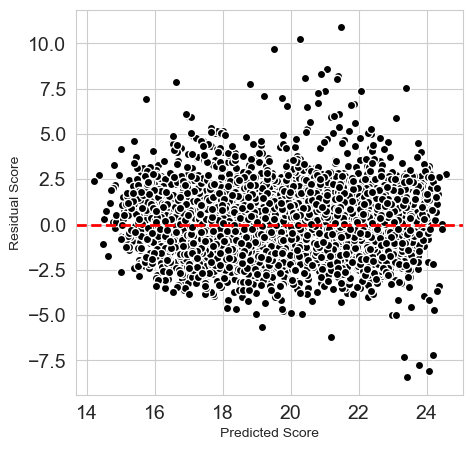

In [33]:
y_hat = multivariate_model_significant.predict()

plt.figure(figsize=(5,5))

plt.plot(y_hat, multivariate_model_significant.resid, 'ko',mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted Score')
plt.ylabel('Residual Score')

plt.tick_params(labelsize=14)

plt.show()

The residual plot looks like a random cloud of plots, and does not appear to show indiciation that another type of linear model such as a polynominal would provide significant benefit

### Reducing the Model to Three Predictors
As an extreme example, we will take three of the predictors from the provided EdGap dataset and compare the explanatory power of a simplier model:

In [34]:
model_reduced = smf.ols(
    formula='average_act ~ rate_unemployment + percent_college + percent_lunch'
    ,data=df_final).fit()

In [35]:
print(model_reduced.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.629
Model:                            OLS   Adj. R-squared:                  0.629
Method:                 Least Squares   F-statistic:                     4100.
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:36:48   Log-Likelihood:                -13380.
No. Observations:                7251   AIC:                         2.677e+04
Df Residuals:                    7247   BIC:                         2.680e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            22.6633      0.10

* This reduced model has 96% of the explanatory power (R-sq of 0.629 vs 0.651) of my final multivariate model, and uses 78% fewer predictors (3 vs 14)
* The F Statistic is almost 1000 point higher and equally significant
* Note that the multicollinearity warning is no longer present in the above model summary

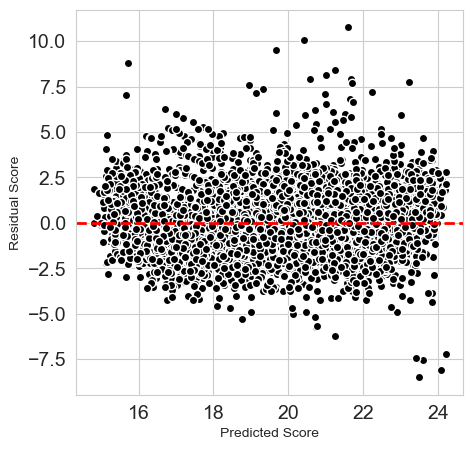

In [36]:
y_hat = model_reduced.predict()

plt.figure(figsize=(5,5))

plt.plot(y_hat, model_reduced.resid, 'ko',mec='w')
plt.axhline(0, color='r', linestyle='dashed', lw=2)

plt.xlabel('Predicted Score')
plt.ylabel('Residual Score')

plt.tick_params(labelsize=14)

plt.show()

The residuals show the same randomness as we saw with the larger model

In [37]:
anova_lm(model_reduced,multivariate_model_significant)

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,7247.0,17012.082421,0.0,NaN,NaN,NaN
1,7195.0,15789.080622,52.0,1223.001799,10.717604,4.411765e-82


We can see here that our residual sum of squares has reduced quite a bit, from 17k to to 15.7k. The P-value for our F Stat is extremely significant, but the F-stat itself is somewhat weak at 10.7. Ultimately, adding 781 degrees of freedom for a F-Stat smaller than 10 tells us the reduced model may still be the better option.

While we did reduce the Residual Sum of Squares by nearly 2k, we also introduced significantly more model complexity. By using an additional 11 variables we only improved our models explanatory power by 2% (R-Squared improvement from 0.629 to 0.651). We know that these changes were statistically significant as shown by the F statistic and corresponding P-Value in our Anova test; but common sense tells us that these changes are marginal and not a solid justification. 

In [38]:
model_percent_lunch = smf.ols(formula='average_act ~ percent_lunch', data=df_final).fit()

In [39]:
print(model_percent_lunch.summary())

                            OLS Regression Results                            
Dep. Variable:            average_act   R-squared:                       0.616
Model:                            OLS   Adj. R-squared:                  0.615
Method:                 Least Squares   F-statistic:                 1.161e+04
Date:                Mon, 20 Oct 2025   Prob (F-statistic):               0.00
Time:                        23:36:48   Log-Likelihood:                -13512.
No. Observations:                7251   AIC:                         2.703e+04
Df Residuals:                    7249   BIC:                         2.704e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
Intercept        23.7458      0.037    642.537

A single variate model confirms that the vast majority of the explanatory power comes from the percent_lunch predictor